In [7]:
from pathlib import Path
import os
import tensorflow as tf

In [8]:
dataset_path= Path("../datasets")

In [9]:
classes = os.listdir(dataset_path)
print(f"Classes found: {classes}")

Classes found: ['Potato___Early_blight', 'Potato___healthy', 'Potato___Late_blight']


In [10]:
for class_name in classes:
    class_path= dataset_path/class_name
    print(class_name,":", len(os.listdir(class_path)), "images")

Potato___Early_blight : 1000 images
Potato___healthy : 152 images
Potato___Late_blight : 1000 images


In [11]:
import matplotlib.pyplot as plt
from PIL import Image

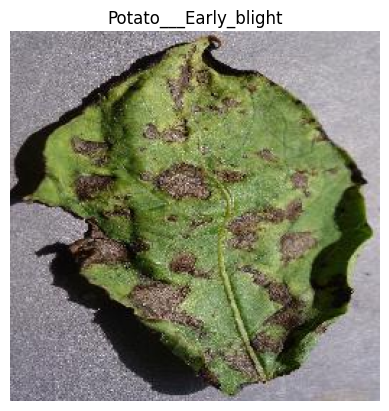

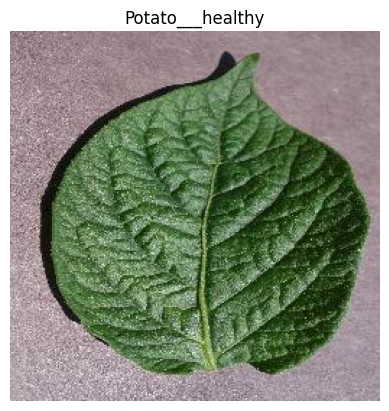

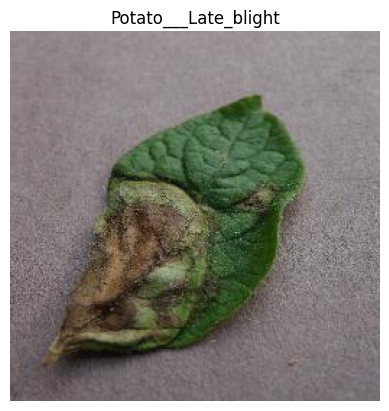

In [12]:
for class_name in classes:
    class_path= dataset_path/class_name
    image_name= os.listdir(class_path)[0]
    image_path= class_path/image_name
    img= Image.open(image_path)
    plt.figure()
    plt.imshow(img)
    plt.title(class_name)
    plt.axis("off")
    plt.show()

In [13]:
size=(224,224)
batch_size=32
train_ds= tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=size,
    batch_size=batch_size

)

valid_ds= tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=size,
    batch_size=batch_size

)

Found 2152 files belonging to 3 classes.
Using 1722 files for training.
Found 2152 files belonging to 3 classes.
Using 430 files for validation.


Class names: ['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']
Image batch shape: (32, 224, 224, 3)
Label batch shape: (32,)
Labels: [1 1 1 0 0 0 0 0 1 1 1 1 0 1 0 1 1 1 0 1 0 1 0 0 1 0 0 1 1 2 0 0]
(32, 224, 224, 3)
(32, 224, 224, 3)
(32, 224, 224, 3)
(32, 224, 224, 3)
(32, 224, 224, 3)
(32, 224, 224, 3)
(32, 224, 224, 3)
(32, 224, 224, 3)
(32, 224, 224, 3)


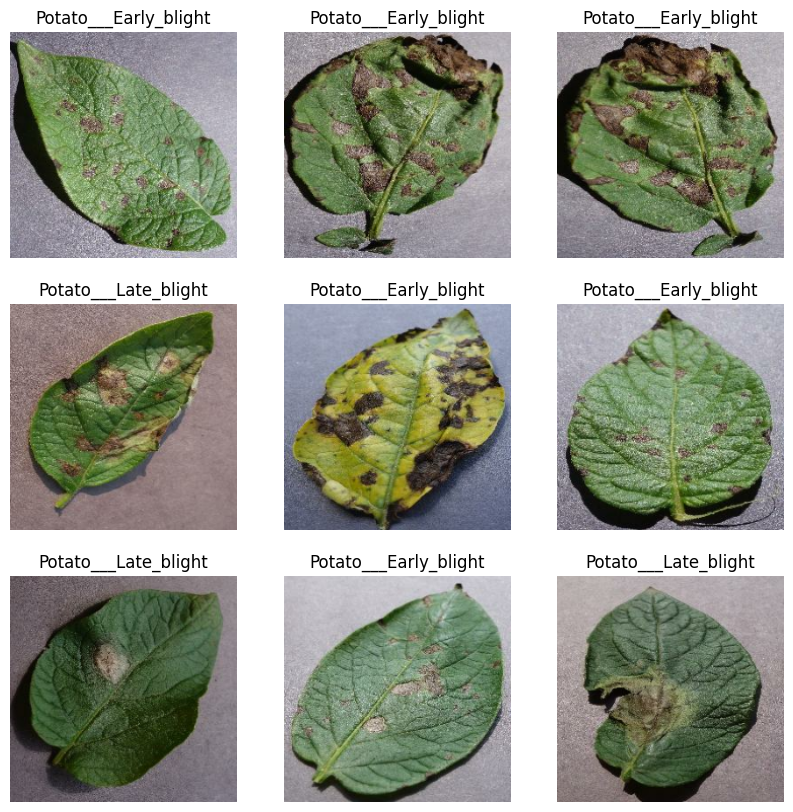

In [14]:
class_names= valid_ds.class_names
print(f"Class names: {class_names}")

import matplotlib.pyplot as plt
import numpy as np

for images, labels in train_ds.take(1):
    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels.shape)
    print("Labels:", labels.numpy())


plt.figure(figsize=(10,10))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax= plt.subplot(3,3,i+1)
        print(images.shape)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")


In [15]:
import tensorflow as tf
data_augmentation= tf.keras.Sequential([
    tf.keras.layers.RandomFlip(("horiontal")),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])

Rescaling image pixels to a value betweeen 0 and 1

In [23]:
normalization_layer= tf.keras.layers.Rescaling(1./255)
from tensorflow.keras import layers, models

model= models.Sequential([
    layers.Input(shape=(224,224,3)),
    data_augmentation,
    layers.Rescaling(1./255, input_shape=(224, 224, 3)),

    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dense(3, activation="softmax")




])



model.compile(
    optimizer= "adam",
    loss= "sparse_categorical_crossentropy",
    metrics= ["accuracy"]
)
model.summary()




Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_3 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_7 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,347 (42.61 MB)

 Trainable params: 11,169,347 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [24]:
history= model.fit(
    train_ds, 
    validation_data= valid_ds,
    epochs=10
)

Epoch 1/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 21s 352ms/step - accuracy: 0.6852 - loss: 0.8144 - val_accuracy: 0.8651 - val_loss: 0.4015
Epoch 2/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 19s 356ms/step - accuracy: 0.8850 - loss: 0.2983 - val_accuracy: 0.8907 - val_loss: 0.3053
Epoch 3/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 20s 371ms/step - accuracy: 0.8693 - loss: 0.3395 - val_accuracy: 0.9023 - val_loss: 0.3030
Epoch 4/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 21s 383ms/step - accuracy: 0.9367 - loss: 0.1716 - val_accuracy: 0.8953 - val_loss: 0.2599
Epoch 5/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 21s 393ms/step - accuracy: 0.9280 - loss: 0.1787 - val_accuracy: 0.8977 - val_loss: 0.2895
Epoch 6/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 22s 404ms/step - accuracy: 0.9233 - loss: 0.2288 - val_accuracy: 0.9116 - val_loss: 0.2182
Epoch 7/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 22s 402ms/step - accuracy: 0.9559 - loss: 0.1225 - val_accuracy: 0.8884 - val_loss: 0.2512
Epoch 8/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 22s 415ms/step - accuracy: 0.9564 - loss: 0.1103 - val_accu

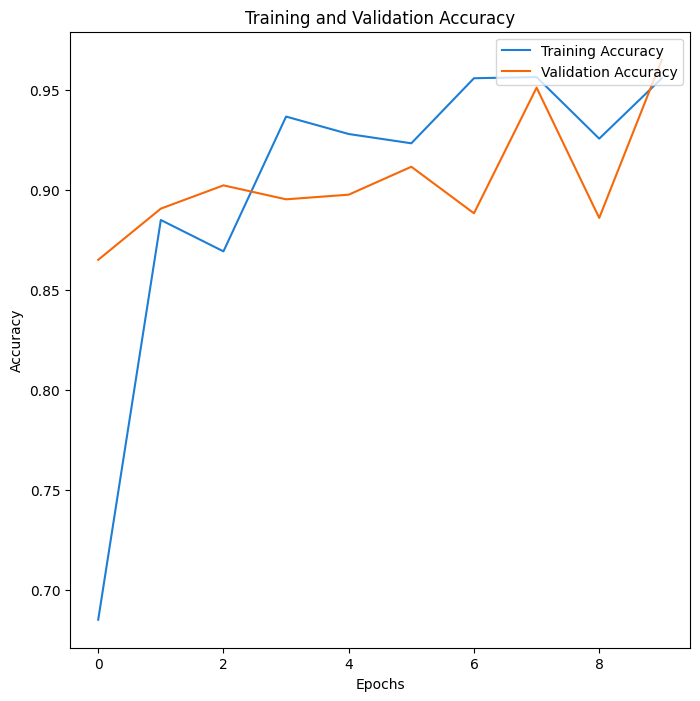

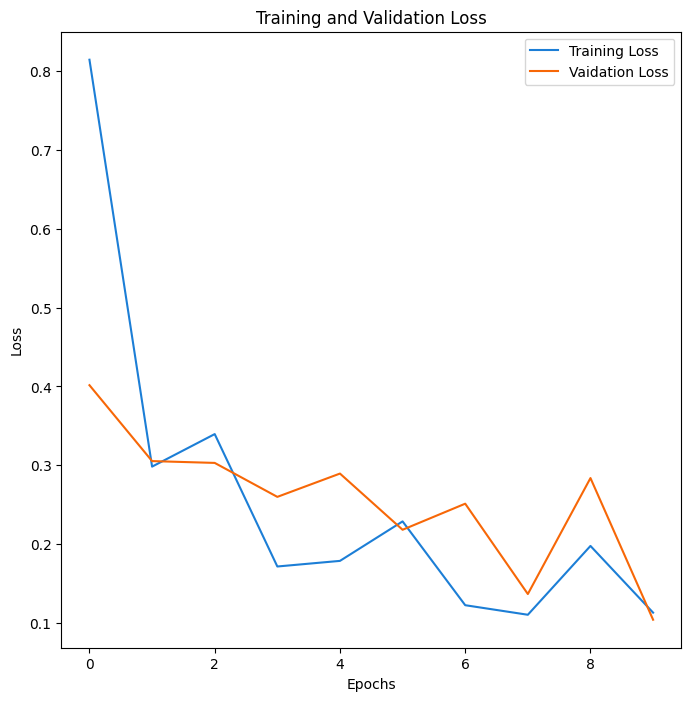

In [25]:
acc= history.history["accuracy"]
val_acc=history.history["val_accuracy"]

acc_loss= history.history["loss"]
val_loss= history.history["val_loss"]
epochs= range(len(acc))

plt.figure(figsize=(8,8))
plt.plot(epochs, acc, label= "Training Accuracy", color= "#1c7ed6")
plt.plot(epochs, val_acc, label= "Validation Accuracy", color= "#f76707")
plt.title("Training and Validation Accuracy")
plt.legend(loc="upper right")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.show()


plt.figure(figsize=(8,8))
plt.plot(epochs, acc_loss, label= "Training Loss", color= "#1c7ed6")
plt.plot(epochs, val_loss, label= "Vaidation Loss", color= "#f76707")
plt.title("Training and Validation Loss")
plt.legend(loc="upper right")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 395ms/step
['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']
Predictions shape: (32, 3)
Actual labels:    [0 0 0 0 0 1 0 1 1 0 0 0 1 1 1 1 1 1 0 0 0 0 1 1 1 2 0 1 0 1 0 0]
Predicted labels: [0 0 0 0 0 1 0 1 1 0 0 0 1 1 1 1 1 1 0 0 0 0 1 1 1 2 0 1 0 1 0 0]


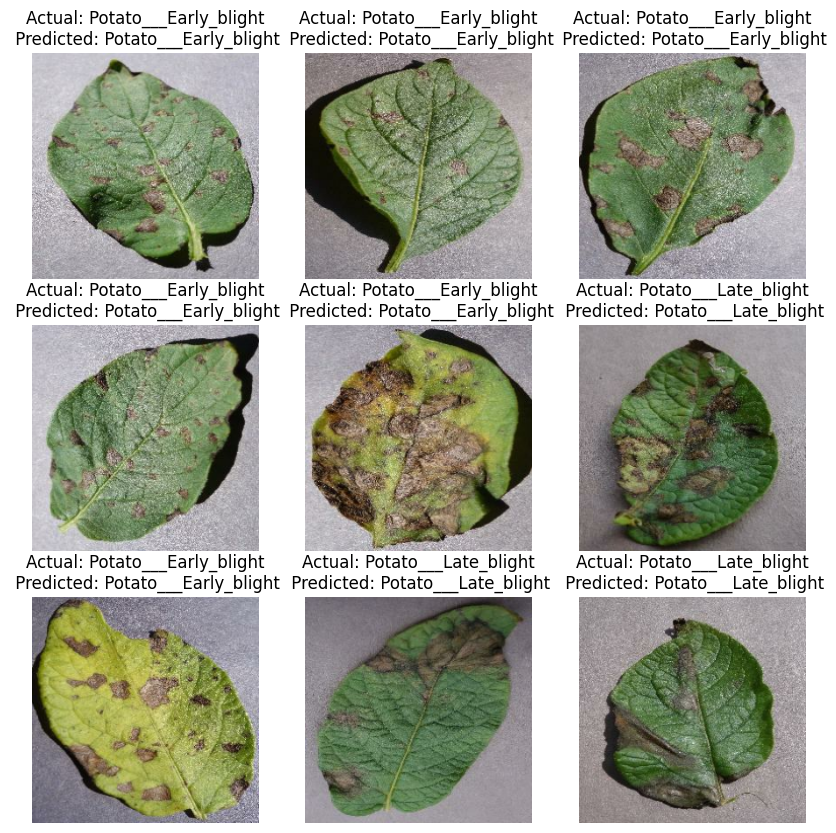

In [26]:
for images, labels in valid_ds.take(1):
    model_predictions= model.predict(images)
    model_labels= np.argmax(model_predictions, axis=1)

    print(class_names)
    print("Predictions shape:", model_predictions.shape)
    # print("Predictions:", model_predictions)
    print("Actual labels:   ", labels.numpy())

    print("Predicted labels:", model_labels)
    plt.figure(figsize=(10,10))
    for i in range(9):
        ax= plt.subplot(3,3, i+1)
        plt.imshow(images.numpy()[i].astype("uint8"))
        plt.title(f"Actual: {class_names[labels[i]]}\n Predicted: {class_names[model_labels[i]]}")
        plt.axis("off")


Image array shape: (224, 224, 3)
Expanded image array shape: (1, 224, 224, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 235ms/step
(1, 3)
Predicted class: Potato___Early_blight
Confidence: 85.14%


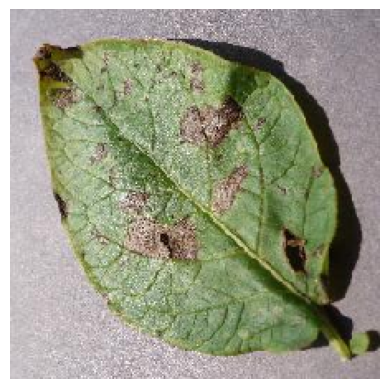

In [27]:
image_path="../datasets/Potato___Early_blight/0a8a68ee-f587-4dea-beec-79d02e7d3fa4___RS_Early.B 8461.JPG"
image_loaded=tf.keras.utils.load_img(image_path, target_size=(224,224))
plt.imshow(image_loaded)
plt.axis("off")

img_array= tf.keras.utils.img_to_array(image_loaded)
print("Image array shape:", img_array.shape)
img_array= np.expand_dims(img_array, axis=0)
print("Expanded image array shape:", img_array.shape)


predictions= model.predict(img_array)
confidence= np.max(predictions)*100
print(predictions.shape)
predicted_class= np.argmax(predictions, axis=1)
print(f"Predicted class: {class_names[predicted_class[0]]}")
print(f"Confidence: {confidence:.2f}%")

In [28]:
model.save("../model/plant_disease_model.keras")

In [29]:
loaded_model = tf.keras.models.load_model("../model/plant_disease_model.keras")
loaded_model.predict(img_array)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step


array([[8.5140538e-01, 1.4858966e-01, 4.9288133e-06]], dtype=float32)